# Pan-cancer hazard ratios using hierarchically normalized disruption scores

This notebook uses the same TCGA inputs and Cox workflow as `hotspot_stratified_hazard_ratios_by_modality.ipynb`. For AlphaGenome modalities, a completed patient-gene is assigned zero only when that modality has a curated track for the patient's cancer tissue; missing tissue modalities are excluded. Scores are standardized sequentially within modality, within modality/gene, and within modality/gene/cancer, then divided by TMB for low/high classification. Each pan-cancer Cox model includes cancer type, TMB, age, and the same gene's disruption scores in the other individual modalities as covariates. `OVERALL_ALPHAGENOME` is excluded from these modality-specific models to avoid overlap with its component modalities. Gene labels are colored by oncogene (orange) or tumor-suppressor-gene (blue) status.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import CoxPHFitter
from scipy.stats import binomtest
from scipy.stats import wilcoxon
from tqdm.auto import tqdm

/Users/an36943/miniforge3/envs/cancer-model/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_ROOT = Path("..").resolve()

PANCANCER_SCORE_PATH = PROJECT_ROOT / "data" / "alphagenome_scores" / "patient_tissue_tracks_local" / "patient_tissue_track_scores.csv"
ALPHAMISSENSE_SCORE_PATH = PROJECT_ROOT / "data" / "alphamissense_combined_gene_level_scores.tsv"
SURVIVAL_PATH = PROJECT_ROOT / "data" / "TCGA" / "survival" / "TCGA_survival_outcome.csv"
TMB_DIR = PROJECT_ROOT / "data" / "TCGA" / "tcga_patient_variants_by_cancer"
HOTSPOT_VARIANT_DIR = PROJECT_ROOT / "data" / "TCGA" / "tcga_driver_gene_hotspot_variants_by_cancer"
DRIVER_GENE_DIR = PROJECT_ROOT / "data" / "driver_genes_coords"
PANCANCER_DRIVER_GENE_PATH = PROJECT_ROOT / "data" / "driver_genes_coords" / "Pancancer_1pc.tsv"
CANCER_GENE_LABEL_PATH = PROJECT_ROOT / "metadata" / "cancer_genes.tsv"
OUTPUT_DIR = PROJECT_ROOT / "results" / "tcga_hotspot_stratified_modality_hazard_ratios_by_cancer"
PLOT_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# None means all available driver cancer types or all top driver genes for each cancer.
SELECTED_CANCER_TYPES = None
SELECTED_GENES = None
SELECTED_MODALITIES = ["ALPHAMISSENSE", "RNA_SEQ", "ATAC", "CHIP_TF", "SPLICE_SITE_USAGE"]  # None means all AlphaGenome output_type values plus AlphaMissense in the assembled table.

SCORE_AGGREGATION_TYPE = "L2_DIFF"
CHIP_TF_UPSTREAM_TSS_BASES = 1_000
CHIP_TF_UPSTREAM_MODALITY = "CHIP_TF_TSS_UPSTREAM_1000BP"
USE_CHIP_TF_UPSTREAM_ONLY = False  # Replace ChIP-TF with its ≤1 kb upstream-of-TSS subset in analyses.
PANCANCER_SCORE_CHUNKSIZE = 500_000
ZERO_TOLERANCE = 0.0
TMB_PSEUDOCOUNT = 1e-6
MIN_GROUP_ROWS = 5
MIN_EVENTS = 5
COX_PENALIZER = 0.1
NORMALIZATION_LEVELS = ['modality', 'gene'] # options are ['modality', 'gene', 'cancer']
MODEL_COVARIATES = ['cancer', 'age'] # options are ['tmb', 'cancer', 'age']

GROUP_ORDER = [
    "0 disruption",
    "Low disruption, no hotspot",
    "High disruption, no hotspot",
    "Hotspot mutation",
]
GROUP_COLORS = {
    "0 disruption": "#666666",
    "Low disruption, no hotspot": "#0072B2",
    "High disruption, no hotspot": "#D55E00",
    "Hotspot mutation": "#CC79A7",
}

In [3]:
def normalize_modality(value):
    return str(value).strip().upper().replace("-", "_")


def normalize_selection(value):
    if value is None:
        return None
    if isinstance(value, str):
        value = [value]
    return [str(item).strip() for item in value if str(item).strip()]


def load_gene_label_colors(path):
    labels = pd.read_csv(path, sep="\t", dtype=str).set_index("Hugo Symbol")
    colors = {}
    for gene, row in labels.iterrows():
        is_og = row["Is Oncogene"] == "Yes"
        is_tsg = row["Is Tumor Suppressor Gene"] == "Yes"
        colors[gene] = "#CC79A7" if is_og and not is_tsg else "#009E73" if is_tsg and not is_og else "gray"
    return colors


GENE_LABEL_COLORS = load_gene_label_colors(CANCER_GENE_LABEL_PATH)


def color_gene_axis_labels(ax):
    for label in ax.get_xticklabels():
        label.set_color(GENE_LABEL_COLORS.get(label.get_text(), "gray"))


def modality_display_name(modality):
    if modality == "CHIP_TF":
        return "ChIP-TF"
    if modality == CHIP_TF_UPSTREAM_MODALITY:
        return "ChIP-TF (mutations ≤1 kb upstream of TSS)"
    return modality.replace("_", "-")



def load_gene_coordinates(path, genes):
    coords = pd.read_csv(path, sep="\t", dtype=str, usecols=["gene", "chr", "strand", "start", "end"])
    coords = coords[coords["gene"].isin(genes)].drop_duplicates("gene")
    return coords.set_index("gene").to_dict("index")


def has_mutation_upstream_of_tss(mutations, gene, gene_coordinates, upstream_bases=CHIP_TF_UPSTREAM_TSS_BASES):
    coord = gene_coordinates.get(str(gene))
    if coord is None or pd.isna(mutations):
        return False

    gene_chrom = str(coord["chr"]).removeprefix("chr")
    if coord["strand"] == "-":
        upstream_start, upstream_end = int(coord["end"]), int(coord["end"]) + upstream_bases
    else:
        tss = int(coord["start"]) - 1
        upstream_start, upstream_end = max(0, tss - upstream_bases), tss

    for mutation in str(mutations).split(";"):
        parts = mutation.split(":")
        if len(parts) != 4 or parts[0].removeprefix("chr") != gene_chrom:
            continue
        start, end = map(int, parts[1].split("-"))
        mutation_start, mutation_end = min(start, end) - 1, max(start, end)
        if mutation_start < upstream_end and mutation_end > upstream_start:
            return True
    return False


def add_chip_tf_upstream_tss_scores(score_df, gene_coordinates):
    chip_tf = score_df["modality"].eq("CHIP_TF")
    chip_tf_scores = score_df.loc[chip_tf].copy()
    if chip_tf_scores.empty:
        return score_df
    upstream = chip_tf_scores.apply(
        lambda row: has_mutation_upstream_of_tss(row["mutations"], row["gene"], gene_coordinates), axis=1
    )
    upstream_scores = chip_tf_scores.loc[upstream].copy()
    upstream_scores["modality"] = CHIP_TF_UPSTREAM_MODALITY
    return pd.concat([score_df, upstream_scores], ignore_index=True)


def slug(value):
    return str(value).strip().replace(" ", "_").replace("/", "_").replace("-", "_")


def add_bh_q_values(df, p_col="p", q_col="q"):
    df = df.copy()
    df[q_col] = np.nan
    if df.empty or p_col not in df.columns:
        return df

    p_values = pd.to_numeric(df[p_col], errors="coerce")
    valid = p_values.notna() & np.isfinite(p_values)
    if not valid.any():
        return df

    valid_p = p_values.loc[valid].astype(float)
    order = valid_p.sort_values().index
    ranked = valid_p.loc[order].to_numpy()
    n_tests = len(ranked)
    q_values = ranked * n_tests / np.arange(1, n_tests + 1)
    q_values = np.minimum.accumulate(q_values[::-1])[::-1]
    q_values = np.clip(q_values, 0, 1)
    df.loc[order, q_col] = q_values
    return df


def load_survival(path):
    survival = pd.read_csv(path, dtype={"bcr_patient_barcode": str}).rename(
        columns={
            "bcr_patient_barcode": "patient_id",
            "type": "cancer",
            "age_at_initial_pathologic_diagnosis": "age",
        }
    )
    survival["OS.time"] = pd.to_numeric(survival["OS.time"], errors="coerce")
    survival["OS"] = pd.to_numeric(survival["OS"], errors="coerce")
    survival["age"] = pd.to_numeric(survival["age"], errors="coerce")
    survival["gender"] = survival["gender"].astype(str).str.upper().replace({"[NOT AVAILABLE]": np.nan, "NAN": np.nan})
    survival = survival.dropna(subset=["patient_id", "cancer", "OS.time", "OS"])
    survival = survival[survival["OS.time"] > 0].copy()
    return survival[["patient_id", "cancer", "OS.time", "OS", "age", "gender"]]



def load_tmb(cancer_type):
    path = TMB_DIR / f"{cancer_type}_tmb.tsv"
    try:
        tmb = pd.read_csv(path, sep="	", dtype={"bcr_patient_barcode": str})
    except pd.errors.EmptyDataError:
        return pd.DataFrame(columns=["patient_id", "tmb", "total_mutations"])
    tmb = tmb.rename(columns={"bcr_patient_barcode": "patient_id"})
    tmb["total_mutations"] = pd.to_numeric(tmb["total_mutations"], errors="coerce")
    tmb = tmb.dropna(subset=["patient_id", "total_mutations"])
    tmb["tmb"] = np.log1p(tmb["total_mutations"].astype(float))
    return tmb[["patient_id", "tmb", "total_mutations"]].drop_duplicates("patient_id")


In [4]:
def load_hotspot_status(cancer_type, genes):
    path = HOTSPOT_VARIANT_DIR / f"{cancer_type}_variants.tsv"
    usecols = ["bcr_patient_barcode", "gene_name", "is_hotspot"]
    variants = pd.read_csv(path, sep="	", dtype=str, usecols=usecols).rename(
        columns={"bcr_patient_barcode": "patient_id", "gene_name": "gene"}
    )
    variants = variants[variants["gene"].isin(genes)].copy()
    variants["is_hotspot"] = variants["is_hotspot"].astype(str).str.lower().eq("true")
    if variants.empty:
        return pd.DataFrame(columns=["patient_id", "gene", "has_hotspot"])
    return (
        variants.groupby(["patient_id", "gene"], as_index=False)["is_hotspot"]
        .any()
        .rename(columns={"is_hotspot": "has_hotspot"})
    )




In [5]:
def tmb_adjusted_disruption(values, tmb, pseudocount=TMB_PSEUDOCOUNT):
    values = np.asarray(values, dtype=float)
    tmb = np.asarray(tmb, dtype=float)
    adjusted = np.full_like(values, np.nan, dtype=float)
    valid = np.isfinite(values) & np.isfinite(tmb)
    adjusted[valid] = values[valid] / (tmb[valid] + pseudocount)
    return adjusted




In [6]:
def available_tmb_cancers():
    return sorted(path.name.removesuffix("_tmb.tsv") for path in TMB_DIR.glob("*_tmb.tsv"))


def selected_pancancer_cancers():
    selected = normalize_selection(SELECTED_CANCER_TYPES)
    available = available_tmb_cancers()
    return available if selected is None else selected


def load_pancancer_driver_genes():
    genes = pd.read_csv(PANCANCER_DRIVER_GENE_PATH, sep="\t", dtype=str, usecols=["gene"])["gene"]
    genes = list(dict.fromkeys(genes.dropna().astype(str)))
    selected = normalize_selection(SELECTED_GENES)
    if selected is None:
        return genes
    return [gene for gene in selected if gene in genes]


def load_pancancer_modality_scores(score_path, patient_ids_by_cancer, genes):
    selected_modalities = normalize_selection(SELECTED_MODALITIES)
    selected_modalities = None if selected_modalities is None else {normalize_modality(m) for m in selected_modalities}
    if selected_modalities is not None and "CHIP_TF" in selected_modalities:
        selected_modalities.add(CHIP_TF_UPSTREAM_MODALITY)
    selected_cancer_set = set(patient_ids_by_cancer)
    selected_patient_ids = set().union(*patient_ids_by_cancer.values()) if patient_ids_by_cancer else set()
    selected_genes = set(genes)
    usecols = [
        "patient_id",
        "cancer_type",
        "gene",
        "gene_strand",
        "output_type",
        "scorer",
        "aggregation_type",
        "score",
        "track_strand",
        "mutations",
    ]
    frames = []
    gene_coordinates = load_gene_coordinates(PANCANCER_DRIVER_GENE_PATH, selected_genes)

    for chunk in tqdm(pd.read_csv(score_path, usecols=usecols, dtype={"patient_id": str}, chunksize=PANCANCER_SCORE_CHUNKSIZE), desc="Loading pancancer AlphaGenome scores"):
        chunk = chunk[
            chunk["cancer_type"].isin(selected_cancer_set)
            & chunk["patient_id"].isin(selected_patient_ids)
            & chunk["gene"].isin(selected_genes)
            & chunk["scorer"].eq("PATIENT_SINGLE_TRACK_SCORER")
            & chunk["aggregation_type"].eq(SCORE_AGGREGATION_TYPE)
        ].copy()
        if chunk.empty:
            continue

        chunk["modality"] = chunk["output_type"].map(normalize_modality)
        if selected_modalities is not None:
            source_modalities = selected_modalities - {CHIP_TF_UPSTREAM_MODALITY}
            if CHIP_TF_UPSTREAM_MODALITY in selected_modalities:
                source_modalities.add("CHIP_TF")
            chunk = chunk[chunk["modality"].isin(source_modalities)]
        chunk = add_chip_tf_upstream_tss_scores(chunk, gene_coordinates)
        if selected_modalities is not None:
            chunk = chunk[chunk["modality"].isin(selected_modalities)]
        if chunk.empty:
            continue

        chunk["score"] = pd.to_numeric(chunk["score"], errors="coerce")
        chunk = chunk.dropna(subset=["score"])
        group_cols = ["patient_id", "cancer_type", "gene", "modality"]
        strand_match = chunk["track_strand"].eq(chunk["gene_strand"])
        has_strand_match = strand_match.groupby([chunk[col] for col in group_cols]).transform("any")
        chunk = chunk[(has_strand_match & strand_match) | (~has_strand_match & chunk["track_strand"].eq("."))]
        frames.append(chunk[["patient_id", "cancer_type", "gene", "modality", "score"]])

    if not frames:
        return pd.DataFrame(columns=["patient_id", "cancer", "gene", "modality", "gene_disruption"])

    scores = pd.concat(frames, ignore_index=True).rename(columns={"cancer_type": "cancer"})
    scores = scores.groupby(["patient_id", "cancer", "gene", "modality"], as_index=False)["score"].median()
    return scores.rename(columns={"score": "gene_disruption"})


def load_pancancer_alphamissense_scores(patient_ids_by_cancer, genes):
    selected_modalities = normalize_selection(SELECTED_MODALITIES)
    selected_modalities = None if selected_modalities is None else {normalize_modality(m) for m in selected_modalities}
    if selected_modalities is not None and "ALPHAMISSENSE" not in selected_modalities:
        return pd.DataFrame(columns=["patient_id", "cancer", "gene", "modality", "gene_disruption"])

    selected_cancer_set = set(patient_ids_by_cancer)
    selected_patient_ids = set().union(*patient_ids_by_cancer.values()) if patient_ids_by_cancer else set()
    usecols = ["bcr_patient_barcode", "cancer_type", "gene", "combined_pathogenicity_burden"]
    scores = pd.read_csv(ALPHAMISSENSE_SCORE_PATH, sep="\t", dtype={"bcr_patient_barcode": str}, usecols=usecols).rename(
        columns={
            "bcr_patient_barcode": "patient_id",
            "cancer_type": "cancer",
            "combined_pathogenicity_burden": "gene_disruption",
        }
    )
    scores = scores[
        scores["cancer"].isin(selected_cancer_set)
        & scores["patient_id"].isin(selected_patient_ids)
        & scores["gene"].isin(genes)
    ].copy()
    scores["gene_disruption"] = pd.to_numeric(scores["gene_disruption"], errors="coerce")
    scores = scores.dropna(subset=["gene_disruption"])
    scores["modality"] = "ALPHAMISSENSE"
    scores = scores.groupby(["patient_id", "cancer", "gene", "modality"], as_index=False)["gene_disruption"].sum()
    return scores[["patient_id", "cancer", "gene", "modality", "gene_disruption"]]

PANCANCER_COMPLETION_LEDGER_PATH = PANCANCER_SCORE_PATH.with_name('patient_tissue_track_scores.completed_patient_genes.tsv')
PANCANCER_TRACK_MAPPING_PATH = PROJECT_ROOT / 'metadata' / 'cancer_tissue_alphagenome_tracks.tsv'

def load_pancancer_completed_gene_pairs(patient_ids, genes):
    completed = pd.read_csv(PANCANCER_COMPLETION_LEDGER_PATH, sep='\t', dtype=str)
    return completed[completed['patient_id'].isin(patient_ids) & completed['gene'].isin(genes)][['patient_id', 'gene']].drop_duplicates()

def load_available_modalities_by_cancer(cancers):
    tracks = pd.read_csv(PANCANCER_TRACK_MAPPING_PATH, sep='\t', dtype=str)
    tracks = tracks[tracks['cancer_type'].isin(cancers)].copy()
    tracks['modality'] = tracks['output_type'].str.replace('OutputType.', '', regex=False).map(normalize_modality)
    available = tracks[['cancer_type', 'modality']].drop_duplicates().rename(columns={'cancer_type': 'cancer'})
    selected = normalize_selection(SELECTED_MODALITIES)
    if selected is not None:
        selected = {normalize_modality(modality) for modality in selected}
        available = available[available['modality'].isin(selected)]
    if selected is None or 'CHIP_TF' in selected:
        upstream = available[available['modality'].eq('CHIP_TF')].copy()
        upstream['modality'] = CHIP_TF_UPSTREAM_MODALITY
        available = pd.concat([available, upstream], ignore_index=True)
    return available.drop_duplicates()

def assign_pancancer_groups(df, split_score_col="tmb_adjusted_gene_disruption"):
    rows = []
    required_cols = list(dict.fromkeys(["gene_disruption", split_score_col]))
    for (gene, modality), group_df in df.groupby(["gene", "modality"], sort=True):
        group_df = group_df.dropna(subset=required_cols).copy()
        group_df["disruption_group"] = pd.NA

        hotspot_mask = group_df["has_hotspot"].fillna(False).astype(bool)
        zero_mask = (~hotspot_mask) & (group_df["gene_disruption"] <= ZERO_TOLERANCE)
        split_mask = (~hotspot_mask) & (group_df["gene_disruption"] > ZERO_TOLERANCE)

        group_df.loc[hotspot_mask, "disruption_group"] = "Hotspot mutation"
        group_df.loc[zero_mask, "disruption_group"] = "0 disruption"
        if split_mask.any():
            median_value = group_df.loc[split_mask, split_score_col].median()
            group_df.loc[split_mask & (group_df[split_score_col] <= median_value), "disruption_group"] = "Low disruption, no hotspot"
            group_df.loc[split_mask & (group_df[split_score_col] > median_value), "disruption_group"] = "High disruption, no hotspot"
        rows.append(group_df.dropna(subset=["disruption_group"]))
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def build_pancancer_analysis_table():
    survival_df = load_survival(SURVIVAL_PATH)
    cancers = selected_pancancer_cancers()
    genes = load_pancancer_driver_genes()
    tmb_by_cancer = {cancer: load_tmb(cancer) for cancer in cancers}
    patient_ids_by_cancer = {}
    pair_rows = []
    hotspot_rows = []

    for cancer_type in cancers:
        tmb_df = tmb_by_cancer[cancer_type]
        cohort_patients = survival_df.loc[survival_df["cancer"].eq(cancer_type), "patient_id"].unique()
        patient_ids = sorted(set(cohort_patients) & set(tmb_df["patient_id"]))
        if not patient_ids:
            continue
        patient_ids_by_cancer[cancer_type] = set(patient_ids)
        pair_df = pd.MultiIndex.from_product([patient_ids, genes], names=["patient_id", "gene"]).to_frame(index=False)
        pair_df["cancer"] = cancer_type
        pair_rows.append(pair_df)
        hotspot_rows.append(load_hotspot_status(cancer_type, genes))

    pair_df = pd.concat(pair_rows, ignore_index=True) if pair_rows else pd.DataFrame(columns=["patient_id", "gene", "cancer"])
    completed_pairs = load_pancancer_completed_gene_pairs(set(pair_df['patient_id']), set(genes))
    available_modalities = load_available_modalities_by_cancer(set(patient_ids_by_cancer))
    alphagenome_score_df = load_pancancer_modality_scores(PANCANCER_SCORE_PATH, patient_ids_by_cancer, genes)
    alphagenome_score_df = alphagenome_score_df.merge(available_modalities, on=['cancer', 'modality'], how='inner')
    alphamissense_score_df = load_pancancer_alphamissense_scores(patient_ids_by_cancer, genes)
    score_df = pd.concat([alphagenome_score_df, alphamissense_score_df], ignore_index=True)
    completed_zero_df = pair_df.merge(completed_pairs, on=['patient_id', 'gene'], how='inner').merge(available_modalities, on='cancer', how='inner')
    completed_zero_df['gene_disruption'] = 0.0
    analysis_df = pd.concat([score_df, completed_zero_df], ignore_index=True).drop_duplicates(['patient_id', 'cancer', 'gene', 'modality'], keep='first')

    hotspot_df = pd.concat(hotspot_rows, ignore_index=True) if hotspot_rows else pd.DataFrame(columns=["patient_id", "gene", "has_hotspot"])
    tmb_df = pd.concat([df.assign(cancer=cancer) for cancer, df in tmb_by_cancer.items()], ignore_index=True)
    analysis_df = analysis_df.merge(hotspot_df, on=["patient_id", "gene"], how="left")
    analysis_df = analysis_df.merge(survival_df[["patient_id", "OS.time", "OS", "age", "gender"]], on="patient_id", how="left")
    analysis_df = analysis_df.merge(tmb_df[["patient_id", "cancer", "tmb", "total_mutations"]], on=["patient_id", "cancer"], how="left")
    analysis_df["has_hotspot"] = analysis_df["has_hotspot"].fillna(False).astype(bool)
    analysis_df["tmb_adjusted_gene_disruption"] = tmb_adjusted_disruption(analysis_df["gene_disruption"], analysis_df["tmb"])
    analysis_df = analysis_df.dropna(subset=["OS.time", "OS", "tmb", "modality"])
    return assign_pancancer_groups(analysis_df)

In [7]:
def group_counts(df, group):
    group_df = df[df["disruption_group"].eq(group)]
    return {
        "group_n_rows": len(group_df),
        "group_n_patients": group_df["patient_id"].nunique() if "patient_id" in group_df.columns else len(group_df),
        "group_n_events": int(group_df["OS"].sum()) if "OS" in group_df.columns else np.nan,
    }


def fit_group_hr(cancer_df):
    counts = cancer_df["disruption_group"].value_counts()
    if counts.get("0 disruption", 0) < MIN_GROUP_ROWS or cancer_df["OS"].sum() < MIN_EVENTS:
        return pd.DataFrame()

    model_df = cancer_df[["OS.time", "OS", "disruption_group"]].copy()
    model_df["disruption_group"] = pd.Categorical(model_df["disruption_group"], categories=GROUP_ORDER)
    dummies = pd.get_dummies(model_df["disruption_group"], prefix="group")
    dummies = dummies.drop(columns=["group_0 disruption"], errors="ignore")
    fit_df = pd.concat([model_df[["OS.time", "OS"]], dummies], axis=1)
    if dummies.empty:
        return pd.DataFrame()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cph = CoxPHFitter(penalizer=COX_PENALIZER)
        cph.fit(fit_df, duration_col="OS.time", event_col="OS")

    rows = [{
        "disruption_group": "0 disruption",
        "hazard_ratio": 1.0,
        "hr_lower_95": 1.0,
        "hr_upper_95": 1.0,
        "p": np.nan,
        **group_counts(cancer_df, "0 disruption"),
    }]
    summary = cph.summary
    for group in GROUP_ORDER[1:]:
        term = f"group_{group}"
        if term not in summary.index:
            continue
        rows.append({
            "disruption_group": group,
            "hazard_ratio": summary.loc[term, "exp(coef)"],
            "hr_lower_95": summary.loc[term, "exp(coef) lower 95%"],
            "hr_upper_95": summary.loc[term, "exp(coef) upper 95%"],
            "p": summary.loc[term, "p"],
            **group_counts(cancer_df, group),
        })
    return pd.DataFrame(rows)

In [8]:
# Edit these lists to choose the sequential z-score strata and Cox covariates.

OUTPUT_DIR = PROJECT_ROOT / 'results' / 'tcga_pancancer_hierarchically_normalized_tmb_adjusted_hazard_ratios'
PLOT_DIR = OUTPUT_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
TMB_PSEUDOCOUNT = 1e-6
PRIMARY_ALPHAGENOME_MODALITIES = ['ATAC', 'RNA_SEQ', 'CHIP_TF', 'SPLICE_SITE_USAGE']

def zscore(values):
    values = pd.to_numeric(values, errors='coerce')
    std = values.std(ddof=0)
    return (values - values.mean()) / std if pd.notna(std) and std > 0 else values * 0.0

def add_overall_alphagenome(raw_df):
    available = [m for m in PRIMARY_ALPHAGENOME_MODALITIES if m in set(raw_df['modality'])]
    overall = raw_df[raw_df['modality'].isin(available)].copy()
    keys = ['patient_id', 'cancer', 'gene', 'has_hotspot', 'OS.time', 'OS', 'age', 'gender', 'tmb', 'total_mutations']
    overall = overall.groupby(keys, dropna=False, as_index=False)['gene_disruption'].sum()
    overall['modality'] = 'OVERALL_ALPHAGENOME'
    return pd.concat([raw_df, overall], ignore_index=True)

def normalize_and_adjust(raw_df):
    df = raw_df.copy()
    normalized_col = 'gene_disruption'
    group_cols = []
    for level in NORMALIZATION_LEVELS:
        group_cols.append(level)
        next_col = 'zscore_' + '_'.join(group_cols)
        df[next_col] = df.groupby(group_cols)[normalized_col].transform(zscore)
        normalized_col = next_col
    df['tmb_adjusted_normalized_disruption'] = df[normalized_col] / (df['tmb'] + TMB_PSEUDOCOUNT)
    return df

def assign_adjusted_groups(df):
    rows = []
    for (_, _), group_df in df.groupby(['gene', 'modality'], sort=True):
        group_df = group_df.dropna(subset=['tmb_adjusted_normalized_disruption']).copy()
        hotspot = group_df['has_hotspot'].fillna(False).astype(bool)
        nonzero = (~hotspot) & group_df['gene_disruption'].gt(ZERO_TOLERANCE)
        group_df['disruption_group'] = pd.NA
        group_df.loc[hotspot, 'disruption_group'] = 'Hotspot mutation'
        group_df.loc[(~hotspot) & ~nonzero, 'disruption_group'] = '0 disruption'
        median = group_df.loc[nonzero, 'tmb_adjusted_normalized_disruption'].median()
        group_df.loc[nonzero & group_df['tmb_adjusted_normalized_disruption'].le(median), 'disruption_group'] = 'Low disruption, no hotspot'
        group_df.loc[nonzero & group_df['tmb_adjusted_normalized_disruption'].gt(median), 'disruption_group'] = 'High disruption, no hotspot'
        rows.append(group_df.dropna(subset=['disruption_group']))
    return pd.concat(rows, ignore_index=True)

track_availability_df = load_available_modalities_by_cancer(selected_pancancer_cancers())
for modality, modality_df in track_availability_df.groupby('modality', sort=True):
    print(f"{modality}: {', '.join(sorted(modality_df['cancer'].unique()))}")

raw_df = build_pancancer_analysis_table().drop(columns=['disruption_group', 'tmb_adjusted_gene_disruption'])
normalized_df = normalize_and_adjust(add_overall_alphagenome(raw_df))
MODELED_MODALITIES = sorted(set(normalized_df['modality']) - {'OVERALL_ALPHAGENOME'})
if USE_CHIP_TF_UPSTREAM_ONLY:
    MODELED_MODALITIES = [modality for modality in MODELED_MODALITIES if modality != 'CHIP_TF']
else:
    MODELED_MODALITIES = [modality for modality in MODELED_MODALITIES if modality != CHIP_TF_UPSTREAM_MODALITY]
other_modality_scores = normalized_df[normalized_df['modality'].isin(MODELED_MODALITIES)].pivot_table(index=['patient_id', 'cancer', 'gene'], columns='modality', values='tmb_adjusted_normalized_disruption', aggfunc='first', fill_value=0.0).reindex(columns=MODELED_MODALITIES, fill_value=0.0).fillna(0.0).reset_index()
OTHER_MODALITY_COLUMNS = {modality: f'other_modality_{slug(modality)}' for modality in MODELED_MODALITIES}
other_modality_scores = other_modality_scores.rename(columns=OTHER_MODALITY_COLUMNS)
def add_other_modality_covariates(df):
    return df.merge(other_modality_scores, on=['patient_id', 'cancer', 'gene'], how='left').fillna({column: 0.0 for column in OTHER_MODALITY_COLUMNS.values()})
grouped_df = add_other_modality_covariates(assign_adjusted_groups(normalized_df[normalized_df['modality'].isin(MODELED_MODALITIES)]))
grouped_df.to_csv(OUTPUT_DIR / 'pancancer_normalized_tmb_adjusted_patient_gene_groups.tsv', sep='\t', index=False)
grouped_df.head()


ATAC: ACC, BLCA, BRCA, CHOL, COAD, DLBC, ESCA, KICH, KIRC, KIRP, LIHC, LUAD, LUSC, OV, PAAD, PCPG, READ, SARC, STAD, THCA, UCEC, UCS
CHIP_TF: ACC, BRCA, COAD, DLBC, ESCA, LIHC, LUAD, LUSC, MESO, OV, PAAD, PCPG, PRAD, READ, SARC, SKCM, STAD, TGCT, THCA, UCEC, UCS
CHIP_TF_TSS_UPSTREAM_1000BP: ACC, BRCA, COAD, DLBC, ESCA, LIHC, LUAD, LUSC, MESO, OV, PAAD, PCPG, PRAD, READ, SARC, SKCM, STAD, TGCT, THCA, UCEC, UCS
RNA_SEQ: ACC, BLCA, BRCA, CESC, CHOL, COAD, DLBC, ESCA, GBM, HNSC, KICH, KIRC, KIRP, LAML, LGG, LIHC, LUAD, LUSC, MESO, OV, PAAD, PCPG, PRAD, READ, SARC, SKCM, STAD, TGCT, THCA, THYM, UCEC, UCS, UVM
SPLICE_SITE_USAGE: ACC, BLCA, BRCA, CESC, CHOL, COAD, DLBC, ESCA, GBM, HNSC, KICH, KIRC, KIRP, LAML, LGG, LIHC, LUAD, LUSC, MESO, OV, PAAD, PCPG, PRAD, READ, SARC, SKCM, STAD, TGCT, THCA, THYM, UCEC, UCS, UVM


Loading pancancer AlphaGenome scores: 34it [01:13,  2.15s/it]
/var/folders/kb/00sgh9j520x459vtmckmbyjw0000gp/T/ipykernel_13626/2409842270.py:185: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tmb_df = pd.concat([df.assign(cancer=cancer) for cancer, df in tmb_by_cancer.items()], ignore_index=True)
/var/folders/kb/00sgh9j520x459vtmckmbyjw0000gp/T/ipykernel_13626/2409842270.py:189: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  analysis_df["has_hotspot"] = analysis_df["has_hotspot"].fillna(False).astype(bool)


,patient_id,cancer,gene,modality,gene_disruption,has_hotspot,OS.time,OS,age,gender,...,total_mutations,zscore_modality,zscore_modality_gene,tmb_adjusted_normalized_disruption,disruption_group,other_modality_ALPHAMISSENSE,other_modality_ATAC,other_modality_CHIP_TF,other_modality_RNA_SEQ,other_modality_SPLICE_SITE_USAGE
0,TCGA-05-4382,LUAD,APC,ALPHAMISSENSE,0.1269,False,607.0,0.0,68.0,MALE,...,412639,-1.105057,-0.561691,-0.043440,"Low disruption, no hotspot",-0.043440,0.051425,0.156435,0.017946,0.000333
1,TCGA-05-4397,LUAD,APC,ALPHAMISSENSE,0.1345,False,731.0,1.0,65.0,MALE,...,368204,-1.092551,-0.553242,-0.043167,"Low disruption, no hotspot",-0.043167,0.023364,0.159768,0.068805,0.003914
2,TCGA-06-0188,GBM,APC,ALPHAMISSENSE,0.0850,False,1356.0,1.0,71.0,MALE,...,187884,-1.174003,-0.608277,-0.050090,"Low disruption, no hotspot",-0.050090,0.000000,0.000000,0.285115,0.002005
3,TCGA-06-5416,GBM,APC,ALPHAMISSENSE,1.2895,False,204.0,0.0,23.0,FEMALE,...,1700242,0.808007,0.730905,0.050947,"High disruption, no hotspot",0.050947,0.000000,0.000000,0.199337,0.004450
4,TCGA-13-A5FU,OV,APC,ALPHAMISSENSE,0.1036,False,256.0,1.0,60.0,FEMALE,...,33257,-1.143397,-0.587597,-0.056434,"Low disruption, no hotspot",-0.056434,-0.067941,-0.083632,-0.066072,-0.038867


In [9]:
def fit_group_hr_adjusted_for_cancer(gene_df):
    counts = gene_df['disruption_group'].value_counts()
    if counts.get('0 disruption', 0) < MIN_GROUP_ROWS or gene_df['OS'].sum() < MIN_EVENTS:
        return pd.DataFrame()
    selected_covariates = [covariate for covariate in MODEL_COVARIATES if covariate in {'tmb', 'cancer', 'age'}]
    modeled_modality = gene_df['modality'].iloc[0]
    other_covariate_columns = [column for modality, column in OTHER_MODALITY_COLUMNS.items() if modality != modeled_modality]
    model_df = gene_df[['OS.time', 'OS', 'disruption_group', *selected_covariates, *other_covariate_columns]].copy()
    model_df['disruption_group'] = pd.Categorical(model_df['disruption_group'], categories=GROUP_ORDER)
    group_dummies = pd.get_dummies(model_df['disruption_group'], prefix='group', dtype=float).drop(columns=['group_0 disruption'], errors='ignore')
    continuous_covariates = [covariate for covariate in ['tmb', 'age'] if covariate in selected_covariates]
    for covariate in continuous_covariates:
        model_df[covariate] = zscore(model_df[covariate])
    cancer_dummies = pd.get_dummies(model_df['cancer'], prefix='cancer', drop_first=True, dtype=float) if 'cancer' in selected_covariates else pd.DataFrame(index=model_df.index)
    varying_other_covariates = []
    for column in other_covariate_columns:
        values = pd.to_numeric(model_df[column], errors='coerce')
        if values.std(ddof=0) > 0:
            model_df[column] = zscore(values)
            varying_other_covariates.append(column)
    if group_dummies.empty:
        return pd.DataFrame()
    fit_df = pd.concat([model_df[['OS.time', 'OS', *continuous_covariates, *varying_other_covariates]], group_dummies, cancer_dummies], axis=1).dropna()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        cph = CoxPHFitter(penalizer=COX_PENALIZER)
        cph.fit(fit_df, duration_col='OS.time', event_col='OS')
    rows = [{'disruption_group': '0 disruption', 'hazard_ratio': 1.0, 'hr_standard_error': 0.0, 'hr_lower_95': 1.0, 'hr_upper_95': 1.0, 'p': np.nan, **group_counts(gene_df, '0 disruption')}]
    for group in GROUP_ORDER[1:]:
        term = f'group_{group}'
        if term in cph.summary.index:
            summary = cph.summary.loc[term]
            rows.append({'disruption_group': group, 'hazard_ratio': summary['exp(coef)'], 'hr_standard_error': summary['exp(coef)'] * summary['se(coef)'], 'hr_lower_95': summary['exp(coef) lower 95%'], 'hr_upper_95': summary['exp(coef) upper 95%'], 'p': summary['p'], **group_counts(gene_df, group)})
    return pd.DataFrame(rows)

hr_rows = []
for (gene, modality), gene_df in grouped_df.groupby(['gene', 'modality'], sort=True):
    try:
        result = fit_group_hr_adjusted_for_cancer(gene_df)
    except Exception as exc:
        result = pd.DataFrame({'disruption_group': GROUP_ORDER, 'hazard_ratio': np.nan, 'hr_standard_error': np.nan, 'hr_lower_95': np.nan, 'hr_upper_95': np.nan, 'p': np.nan, 'fit_error': str(exc)})
    if not result.empty:
        result['gene'] = gene
        result['modality'] = modality
        hr_rows.append(result)

hr_df = pd.concat(hr_rows, ignore_index=True)
hr_df = add_bh_q_values(hr_df, 'p', 'q')
hr_path = OUTPUT_DIR / 'pancancer_normalized_cancer_type_tmb_adjusted_hazard_ratios_by_gene_modality.tsv'
hr_df.to_csv(hr_path, sep='\t', index=False)
hr_df.head()

,disruption_group,hazard_ratio,hr_standard_error,hr_lower_95,hr_upper_95,p,group_n_rows,group_n_patients,group_n_events,gene,modality,fit_error,q
0,0 disruption,1.000000,0.000000,1.000000,1.000000,NaN,214.0,214.0,30.0,APC,ATAC,NaN,NaN
1,"Low disruption, no hotspot",1.046009,0.064513,0.926908,1.180412,0.465804,2874.0,2874.0,768.0,APC,ATAC,NaN,0.967550
2,"High disruption, no hotspot",1.012683,0.065466,0.892168,1.149478,0.845424,2873.0,2873.0,800.0,APC,ATAC,NaN,0.982009
3,Hotspot mutation,1.037704,0.245322,0.652892,1.649320,0.875598,70.0,70.0,13.0,APC,ATAC,NaN,0.982009
4,0 disruption,1.000000,0.000000,1.000000,1.000000,NaN,234.0,234.0,31.0,APC,CHIP_TF,NaN,NaN


Saved combined hazard ratio plot for all modalities to /Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_pancancer_hierarchically_normalized_tmb_adjusted_hazard_ratios/plots/PANCANCER_normalized_tmb_adjusted_hazard_ratios_all_modalities.png


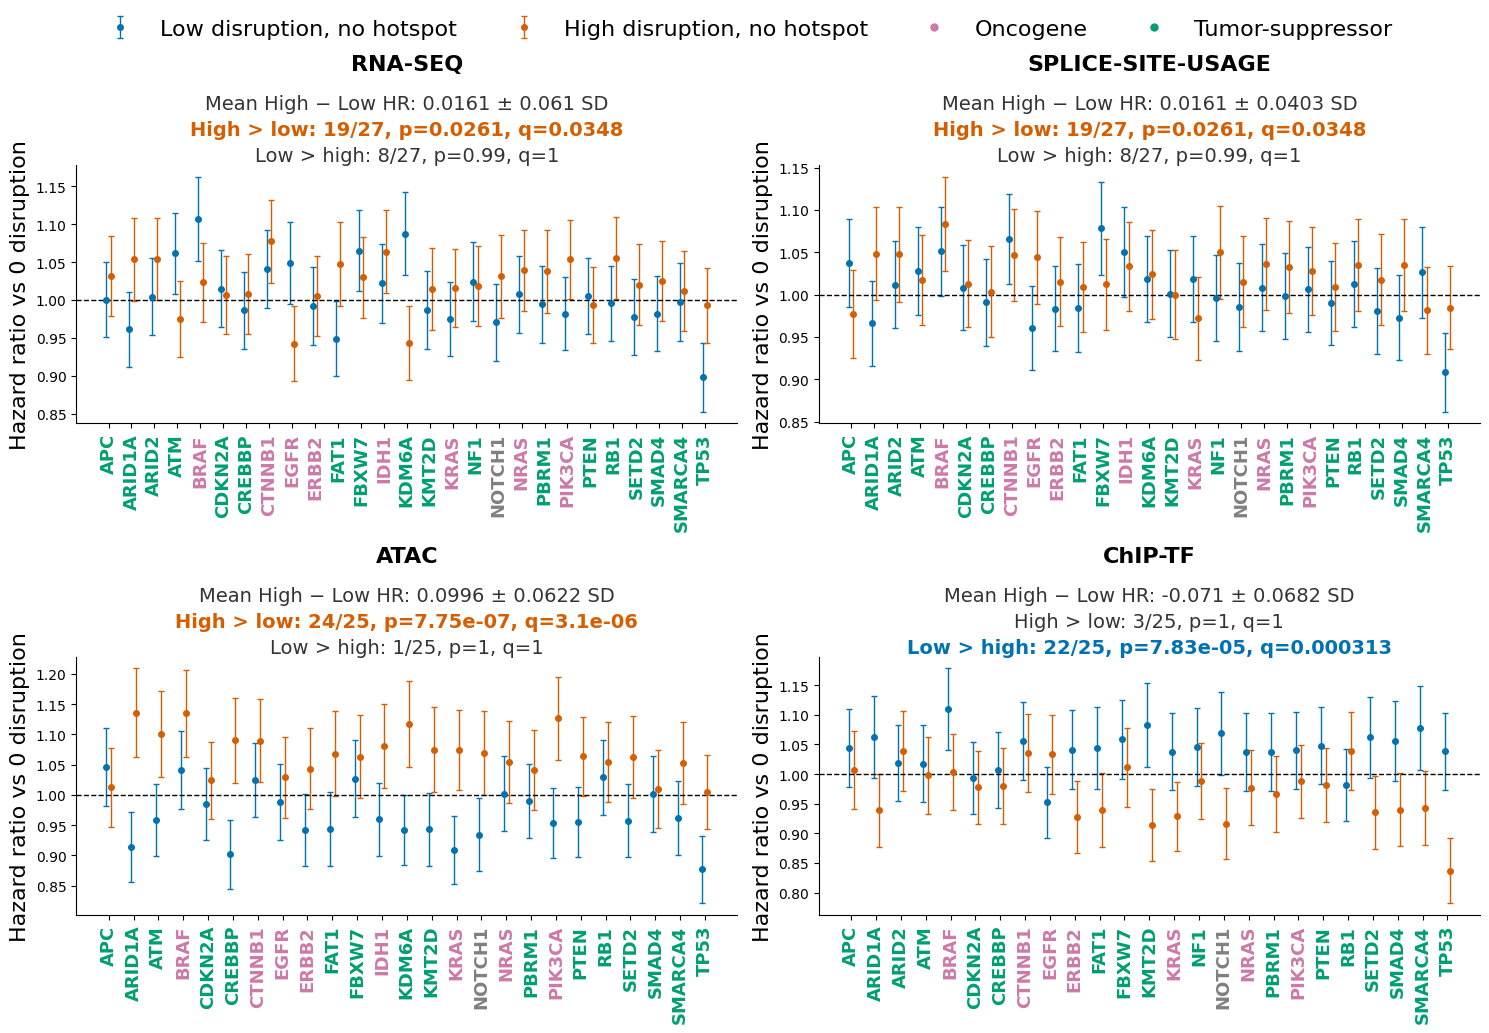

In [10]:
def compare_high_vs_low_by_modality(hr_df):
    rows = []
    groups = ['Low disruption, no hotspot', 'High disruption, no hotspot']
    for modality, modality_df in hr_df.groupby('modality', sort=True):
        pivot = modality_df.pivot_table(index='gene', columns='disruption_group', values='hazard_ratio', aggfunc='first')
        if not set(groups).issubset(pivot.columns):
            continue
        paired = pivot[groups].apply(pd.to_numeric, errors='coerce').dropna()
        n_genes = len(paired)
        n_high_gt_low = int((paired[groups[1]] > paired[groups[0]]).sum())
        n_low_gt_high = int((paired[groups[0]] > paired[groups[1]]).sum())
        hr_difference = paired[groups[1]] - paired[groups[0]]
        rows.append({'modality': modality, 'n_genes_tested': n_genes, 'n_high_hr_gt_low': n_high_gt_low, 'binomial_p_high_gt_low': binomtest(n_high_gt_low, n_genes, p=0.5, alternative='greater').pvalue if n_genes else np.nan, 'n_low_hr_gt_high': n_low_gt_high, 'binomial_p_low_gt_high': binomtest(n_low_gt_high, n_genes, p=0.5, alternative='greater').pvalue if n_genes else np.nan, 'mean_high_minus_low_hr': hr_difference.mean(), 'std_high_minus_low_hr': hr_difference.std(ddof=1)})
    direction_df = add_bh_q_values(pd.DataFrame(rows), 'binomial_p_high_gt_low', 'binomial_q_high_gt_low')
    return add_bh_q_values(direction_df, 'binomial_p_low_gt_high', 'binomial_q_low_gt_high')

def plot_all_modalities_hr(hr_df, direction_df, modality_order):
    groups = ['Low disruption, no hotspot', 'High disruption, no hotspot']
    modalities = [modality for modality in modality_order if modality in set(hr_df['modality'])]
    ncols = 2
    nrows = max(1, int(np.ceil(len(modalities) / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5.2 * nrows), squeeze=False)
    for panel_index, (ax, modality) in enumerate(zip(axes.ravel(), modalities)):
        modality_df = hr_df[hr_df['modality'].eq(modality)].copy()
        visible = modality_df[modality_df['disruption_group'].isin(groups)].copy()
        visible['hazard_ratio'] = pd.to_numeric(visible['hazard_ratio'], errors='coerce')
        visible = visible[np.isfinite(visible['hazard_ratio'])]
        genes = sorted(visible['gene'].dropna().unique())
        for group, offset in zip(groups, [-0.1, 0.1]):
            values = visible[visible['disruption_group'].eq(group)].set_index('gene').reindex(genes).dropna(subset=['hazard_ratio']).reset_index()
            if values.empty:
                continue
            x = np.array([genes.index(gene) for gene in values['gene']]) + offset
            y = values['hazard_ratio'].to_numpy(dtype=float)
            standard_error = pd.to_numeric(values['hr_standard_error'], errors='coerce').to_numpy()
            valid_se = np.isfinite(standard_error) & (standard_error >= 0)
            if valid_se.any():
                ax.errorbar(x[valid_se], y[valid_se], yerr=standard_error[valid_se], fmt='o', capsize=2, markersize=4, linewidth=1, color=GROUP_COLORS[group], label=group)
            if (~valid_se).any():
                ax.plot(x[~valid_se], y[~valid_se], 'o', markersize=4, color=GROUP_COLORS[group], label=None if valid_se.any() else group)
        ax.axhline(1, color='black', linestyle='--', linewidth=1)
        ax.set_xticks(range(len(genes)), genes, rotation=90, fontsize=13, fontweight='bold')
        color_gene_axis_labels(ax)
        ax.set_ylabel('Hazard ratio vs 0 disruption', fontsize=16)
        label = 'Overall AlphaGenome' if modality == 'OVERALL_ALPHAGENOME' else modality_display_name(modality)
        test = direction_df[direction_df['modality'].eq(modality)]
        ax.set_title(label, fontsize=16, pad=68, fontweight='bold')
        if test.empty:
            ax.text(0.5, 1.08, 'No paired high/low HRs', transform=ax.transAxes, ha='center', va='bottom', color='#333333', fontsize=10)
        else:
            row = test.iloc[0]
            high_significant = pd.notna(row['binomial_q_high_gt_low']) and row['binomial_q_high_gt_low'] < 0.05
            low_significant = pd.notna(row['binomial_q_low_gt_high']) and row['binomial_q_low_gt_high'] < 0.05
            difference_label = f"Mean High − Low HR: {row['mean_high_minus_low_hr']:.3g} ± {row['std_high_minus_low_hr']:.3g} SD"
            high_label = f"High > low: {row['n_high_hr_gt_low']}/{row['n_genes_tested']}, p={row['binomial_p_high_gt_low']:.3g}, q={row['binomial_q_high_gt_low']:.3g}"
            low_label = f"Low > high: {row['n_low_hr_gt_high']}/{row['n_genes_tested']}, p={row['binomial_p_low_gt_high']:.3g}, q={row['binomial_q_low_gt_high']:.3g}"
            ax.text(0.5, 1.2, difference_label, transform=ax.transAxes, ha='center', va='bottom', color='#333333', fontsize=14)
            ax.text(0.5, 1.1, high_label, transform=ax.transAxes, ha='center', va='bottom', color='#D55E00' if high_significant else '#333333', fontsize=14, fontweight='bold' if high_significant else 'normal')
            ax.text(0.5, 1.0, low_label, transform=ax.transAxes, ha='center', va='bottom', color='#0072B2' if low_significant else '#333333', fontsize=14, fontweight='bold' if low_significant else 'normal')
        sns.despine(ax=ax)
    for ax in axes.ravel()[len(modalities):]:
        ax.set_visible(False)
    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    gene_handles = [plt.Line2D([0], [0], marker='o', color='w', label='Oncogene', markerfacecolor='#CC79A7', markersize=7), plt.Line2D([0], [0], marker='o', color='w', label='Tumor-suppressor gene', markerfacecolor='#009E73', markersize=7)]
    if handles:
        fig.legend(handles + gene_handles, labels + ['Oncogene', 'Tumor-suppressor'], frameon=False, loc='upper center', ncol=4, fontsize=16)
    # fig.suptitle('Pancancer hazard ratios by modality and gene', y=0.97, fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    return fig

PLOTTED_CHIP_TF_MODALITY = CHIP_TF_UPSTREAM_MODALITY if USE_CHIP_TF_UPSTREAM_ONLY else 'CHIP_TF'
modality_order = ['RNA_SEQ', 'SPLICE_SITE_USAGE', 'ATAC', PLOTTED_CHIP_TF_MODALITY]
plot_hr_df = hr_df[hr_df['modality'].isin(modality_order)].copy()
direction_df = compare_high_vs_low_by_modality(plot_hr_df)
direction_df.to_csv(OUTPUT_DIR / 'pancancer_normalized_tmb_adjusted_high_vs_low_binomial_tests.tsv', sep='\t', index=False)
combined_fig = plot_all_modalities_hr(plot_hr_df, direction_df, modality_order)
combined_path = PLOT_DIR / 'PANCANCER_normalized_tmb_adjusted_hazard_ratios_all_modalities.png'
combined_fig.savefig(combined_path, dpi=300, bbox_inches='tight')
print(f"Saved combined hazard ratio plot for all modalities to {combined_path}")

## Low- and high-disruption HRs across genes

For each modality, the boxes summarize gene-level hazard ratios. Each overlaid point is the low- or high-disruption HR for one gene.

Saved low/high hazard-ratio boxplots to /Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_pancancer_hierarchically_normalized_tmb_adjusted_hazard_ratios/plots/PANCANCER_low_vs_high_hazard_ratio_boxplots_by_modality.png


/var/folders/kb/00sgh9j520x459vtmckmbyjw0000gp/T/ipykernel_13626/825000000.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([modality_display_name(modality) for modality in modalities])


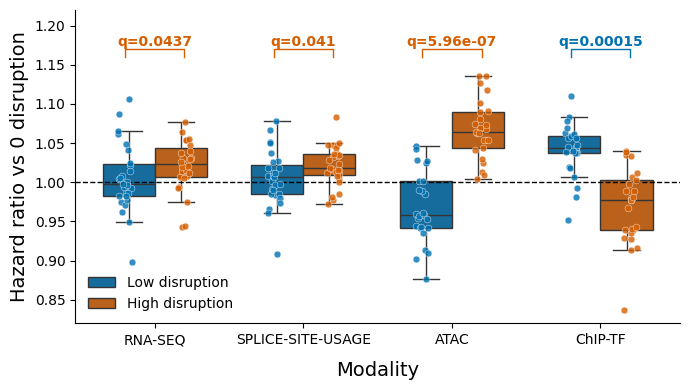

In [11]:
def plot_low_high_hr_boxplots(points_df, modality_order):
    modalities = [modality for modality in modality_order if modality in set(points_df['modality'])]
    test_rows = []
    for modality in modalities:
        paired = points_df.loc[points_df['modality'].eq(modality), ['low_hr', 'high_hr']].dropna()
        try:
            high_greater_p = wilcoxon(paired['high_hr'], paired['low_hr'], alternative='greater').pvalue if len(paired) else np.nan
            low_greater_p = wilcoxon(paired['low_hr'], paired['high_hr'], alternative='greater').pvalue if len(paired) else np.nan
        except ValueError:
            high_greater_p = low_greater_p = 1.0
        test_rows.append({'modality': modality, 'n_genes': len(paired), 'high_greater_p': high_greater_p, 'low_greater_p': low_greater_p})
    test_df = add_bh_q_values(pd.DataFrame(test_rows), 'high_greater_p', 'high_greater_q')
    test_df = add_bh_q_values(test_df, 'low_greater_p', 'low_greater_q')
    plot_df = points_df.melt(
        id_vars=['gene', 'modality'],
        value_vars=['low_hr', 'high_hr'],
        var_name='disruption_group',
        value_name='hazard_ratio',
    ).dropna(subset=['hazard_ratio'])
    group_labels = {'low_hr': 'Low disruption', 'high_hr': 'High disruption'}
    plot_df['disruption_group'] = plot_df['disruption_group'].map(group_labels)
    group_order = ['Low disruption', 'High disruption']
    palette = {
        'Low disruption': GROUP_COLORS['Low disruption, no hotspot'],
        'High disruption': GROUP_COLORS['High disruption, no hotspot'],
    }
    fig, ax = plt.subplots(figsize=(max(7, 1.6 * len(modalities)), 4))
    sns.boxplot(
        data=plot_df, x='modality', y='hazard_ratio', hue='disruption_group',
        order=modalities, hue_order=group_order, palette=palette,
        showfliers=False, width=0.7, ax=ax,
    )
    rng = np.random.default_rng(0)
    for modality_index, modality in enumerate(modalities):
        for group_index, group in enumerate(group_order):
            values = plot_df.loc[
                plot_df['modality'].eq(modality) & plot_df['disruption_group'].eq(group),
                'hazard_ratio',
            ].to_numpy()
            x = modality_index + (-0.2 if group_index == 0 else 0.2) + rng.uniform(-0.045, 0.045, len(values))
            ax.scatter(x, values, color=palette[group], edgecolor='white', linewidth=0.35, s=24, alpha=0.8, zorder=3)
    ax.axhline(1, color='black', linestyle='--', linewidth=1)
    finite_hr = plot_df['hazard_ratio'][np.isfinite(plot_df['hazard_ratio'])]
    hr_span = max(finite_hr.max() - finite_hr.min(), 0.1)
    annotation_y = finite_hr.max() + 0.08 * hr_span
    bracket_height = 0.035 * hr_span
    for modality_index, modality in enumerate(modalities):
        result = test_df.loc[test_df['modality'].eq(modality)].iloc[0]
        high_significant = pd.notna(result['high_greater_q']) and result['high_greater_q'] < 0.05
        low_significant = pd.notna(result['low_greater_q']) and result['low_greater_q'] < 0.05
        if not (high_significant or low_significant):
            continue
        q_value = result['high_greater_q'] if high_significant else result['low_greater_q']
        color = '#D55E00' if high_significant else '#0072B2'
        label = f"q={q_value:.3g}"
        ax.plot([modality_index - 0.2, modality_index - 0.2, modality_index + 0.2, modality_index + 0.2], [annotation_y, annotation_y + bracket_height, annotation_y + bracket_height, annotation_y], color=color, linewidth=1)
        ax.text(modality_index, annotation_y + bracket_height, label, ha='center', va='bottom', fontsize=10, color=color, fontweight='bold')
    if (test_df[['high_greater_q', 'low_greater_q']] < 0.05).any().any():
        ax.set_ylim(top=annotation_y + 0.2 * hr_span)
    ax.set_xlabel('Modality', fontsize=14, labelpad=10)
    ax.set_ylabel('Hazard ratio vs 0 disruption', fontsize=14)
    ax.set_xticklabels([modality_display_name(modality) for modality in modalities])
    ax.legend(title='', frameon=False)
    sns.despine(ax=ax)
    fig.tight_layout()
    return fig, test_df

BOXPLOT_MODALITIES = ['ALPHAMISSENSE', 'RNA_SEQ', 'SPLICE_SITE_USAGE', 'ATAC', PLOTTED_CHIP_TF_MODALITY]
boxplot_groups = ['Low disruption, no hotspot', 'High disruption, no hotspot']
boxplot_points_df = (
    hr_df[hr_df['modality'].isin(BOXPLOT_MODALITIES)]
    .pivot_table(index=['gene', 'modality'], columns='disruption_group', values='hazard_ratio', aggfunc='first')
    .reindex(columns=boxplot_groups)
    .dropna()
    .rename(columns={boxplot_groups[0]: 'low_hr', boxplot_groups[1]: 'high_hr'})
    .reset_index()
)
low_high_hr_boxplot_fig, low_high_hr_boxplot_tests_df = plot_low_high_hr_boxplots(boxplot_points_df, BOXPLOT_MODALITIES)
low_high_hr_boxplot_tests_df.to_csv(OUTPUT_DIR / 'pancancer_low_vs_high_hazard_ratio_boxplot_wilcoxon_tests.tsv', sep='\t', index=False)
low_high_hr_boxplot_path = PLOT_DIR / 'PANCANCER_low_vs_high_hazard_ratio_boxplots_by_modality.png'
low_high_hr_boxplot_fig.savefig(low_high_hr_boxplot_path, dpi=300, bbox_inches='tight')
print(f'Saved low/high hazard-ratio boxplots to {low_high_hr_boxplot_path}')


## Low-versus-high hazard-ratio scatterplots

Each point is a gene with paired low- and high-disruption HRs, colored by oncogene (orange) or tumor-suppressor-gene (blue) status. The dashed diagonal is the null of equal HRs. A two-sided Wilcoxon signed-rank test of `log(HR_high / HR_low)` tests deviation from that diagonal; q-values are BH-adjusted across modalities.


Saved low vs high hazard ratio scatter plot to /Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_pancancer_hierarchically_normalized_tmb_adjusted_hazard_ratios/plots/PANCANCER_low_vs_high_hazard_ratio_scatter_by_modality.png


,modality,n_genes,high_greater_p,low_greater_p,high_greater_q,low_greater_q
0,ATAC,25,1.490116e-07,1.000000,5.960464e-07,1.000000
1,CHIP_TF,25,9.999625e-01,0.000044,9.999625e-01,0.000176
2,RNA_SEQ,27,3.274073e-02,0.969051,4.365430e-02,1.000000
3,SPLICE_SITE_USAGE,27,1.926706e-02,0.981897,3.853412e-02,1.000000


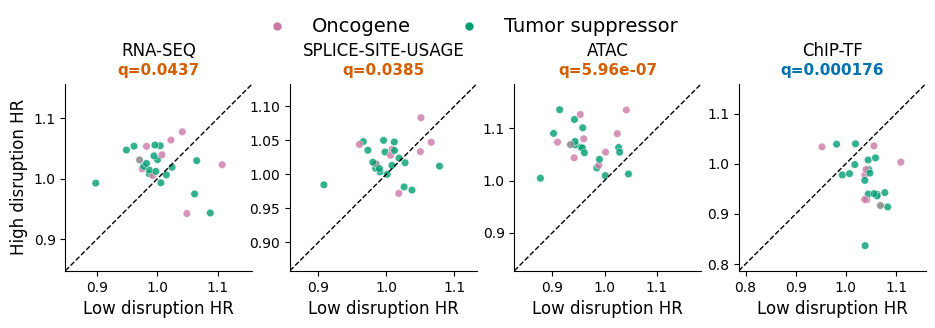

In [12]:
def low_high_hr_scatter_data(hr_df):
    groups, point_rows, test_rows = ['Low disruption, no hotspot', 'High disruption, no hotspot'], [], []
    for modality, modality_df in hr_df.groupby('modality', sort=True):
        pivot = modality_df.pivot_table(index='gene', columns='disruption_group', values='hazard_ratio', aggfunc='first')
        if not set(groups).issubset(pivot.columns):
            continue
        paired = pivot[groups].apply(pd.to_numeric, errors='coerce').dropna()
        paired = paired[(paired[groups[0]] > 0) & (paired[groups[1]] > 0)].rename(columns={groups[0]: 'low_hr', groups[1]: 'high_hr'}).reset_index()
        paired['modality'] = modality
        point_rows.append(paired)
        log_ratio = np.log(paired['high_hr'] / paired['low_hr'])
        try:
            high_greater_p = wilcoxon(log_ratio, alternative='greater').pvalue if len(log_ratio) else np.nan
            low_greater_p = wilcoxon(log_ratio, alternative='less').pvalue if len(log_ratio) else np.nan
        except ValueError:
            high_greater_p = low_greater_p = 1.0
        test_rows.append({'modality': modality, 'n_genes': len(paired), 'high_greater_p': high_greater_p, 'low_greater_p': low_greater_p})
    points = pd.concat(point_rows, ignore_index=True) if point_rows else pd.DataFrame(columns=['gene', 'low_hr', 'high_hr', 'modality'])
    tests = add_bh_q_values(pd.DataFrame(test_rows), 'high_greater_p', 'high_greater_q')
    return points, add_bh_q_values(tests, 'low_greater_p', 'low_greater_q')

def plot_low_high_hr_scatter(points_df, test_df, modality_order):
    modalities = [modality for modality in modality_order if modality in set(points_df['modality'])]
    ncols, nrows = 5, max(1, int(np.ceil(len(modalities) / 2)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows))
    for panel_index, (ax, modality) in enumerate(zip(axes.ravel(), modalities)):
        data = points_df[points_df['modality'].eq(modality)]
        gene_colors = data['gene'].map(GENE_LABEL_COLORS).fillna('#666666')
        ax.scatter(data['low_hr'], data['high_hr'], c=gene_colors, s=30, alpha=0.8, edgecolor='white', linewidth=0.4)
        lower, upper = min(data['low_hr'].min(), data['high_hr'].min()), max(data['low_hr'].max(), data['high_hr'].max())
        padding = max((upper - lower) * 0.05, 0.05)
        limits = (max(0, lower - padding), upper + padding)
        ax.plot(limits, limits, color='black', linestyle='--', linewidth=1)
        ax.set(xlim=limits, ylim=limits, xlabel='Low disruption HR')
        if panel_index == 0:
            ax.set_ylabel('High disruption HR')
        # set x and y label font sizes
        ax.xaxis.label.set_size(12)
        ax.yaxis.label.set_size(12)
        ax.set_aspect('equal', adjustable='box')
        test = test_df[test_df['modality'].eq(modality)]
        row = test.iloc[0] if not test.empty else None
        ax.set_title(modality_display_name(modality), fontsize=12, pad=20)
        if row is not None:
            high_significant = pd.notna(row['high_greater_q']) and row['high_greater_q'] < 0.05
            low_significant = pd.notna(row['low_greater_q']) and row['low_greater_q'] < 0.05
            if high_significant or low_significant:
                q_value = row['high_greater_q'] if high_significant else row['low_greater_q']
                color = '#D55E00' if high_significant else '#0072B2'
                ax.text(0.5, 1.03, f"q={q_value:.3g}", transform=ax.transAxes, ha='center', va='bottom', fontsize=11, color=color, fontweight='bold')
        sns.despine(ax=ax)
    for ax in axes.ravel()[len(modalities):]:
        ax.set_visible(False)
    handles = [plt.Line2D([0], [0], marker='o', color='w', label='Oncogene', markerfacecolor='#CC79A7', markersize=7), plt.Line2D([0], [0], marker='o', color='w', label='Tumor suppressor', markerfacecolor='#009E73', markersize=7)]
    fig.legend(handles=handles, frameon=False, loc='upper center', ncol=2, fontsize=14)
    return fig

SCATTER_MODALITIES = ['ALPHAMISSENSE', 'RNA_SEQ', 'SPLICE_SITE_USAGE', 'ATAC', PLOTTED_CHIP_TF_MODALITY]
scatter_hr_df = hr_df[hr_df['modality'].isin(SCATTER_MODALITIES)]
low_high_scatter_df, low_high_scatter_tests_df = low_high_hr_scatter_data(scatter_hr_df)
low_high_scatter_df.to_csv(OUTPUT_DIR / 'pancancer_low_high_hr_scatter_points.tsv', sep='\t', index=False)
low_high_scatter_tests_df.to_csv(OUTPUT_DIR / 'pancancer_low_high_hr_scatter_wilcoxon_tests.tsv', sep='\t', index=False)
low_high_scatter_fig = plot_low_high_hr_scatter(low_high_scatter_df, low_high_scatter_tests_df, SCATTER_MODALITIES)
low_high_scatter_path = PLOT_DIR / 'PANCANCER_low_vs_high_hazard_ratio_scatter_by_modality.png'
low_high_scatter_fig.savefig(low_high_scatter_path, dpi=300, bbox_inches='tight')
print(f"Saved low vs high hazard ratio scatter plot to {low_high_scatter_path}")
low_high_scatter_tests_df

## Low- and high-disruption HR distributions

Each panel shows the across-gene density of low- and high-disruption hazard ratios for the same modalities used in the scatterplot.


Saved low/high hazard-ratio distribution plot to /Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_pancancer_hierarchically_normalized_tmb_adjusted_hazard_ratios/plots/PANCANCER_low_vs_high_hazard_ratio_distributions_by_modality.png


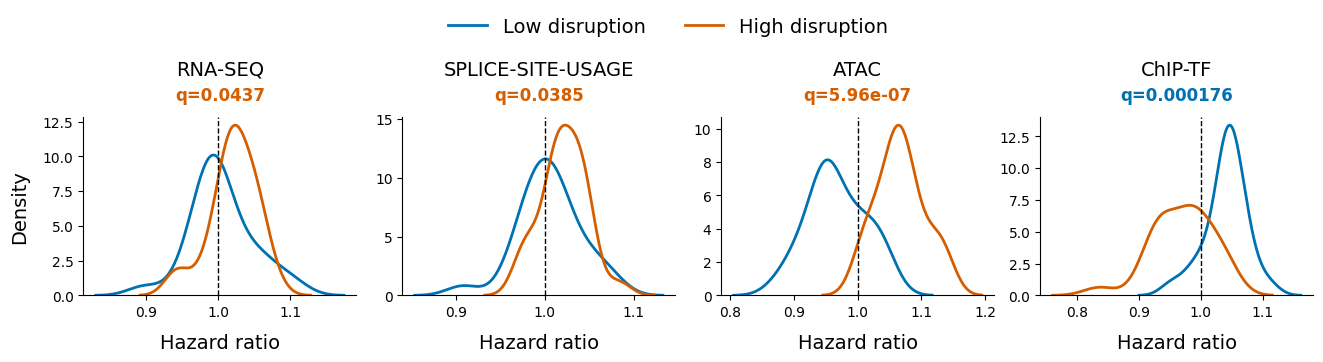

In [13]:
def plot_low_high_hr_distributions(points_df, test_df, modality_order):
    modalities = [modality for modality in modality_order if modality in set(points_df['modality'])]
    ncols = min(4, max(1, len(modalities)))
    nrows = max(1, int(np.ceil(len(modalities) / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.3 * ncols, 3.5 * nrows))
    groups = [('low_hr', 'Low disruption', GROUP_COLORS['Low disruption, no hotspot']), ('high_hr', 'High disruption', GROUP_COLORS['High disruption, no hotspot'])]
    for panel_index, (ax, modality) in enumerate(zip(axes.ravel(), modalities)):
        modality_df = points_df[points_df['modality'].eq(modality)]
        for column, label, color in groups:
            values = pd.to_numeric(modality_df[column], errors='coerce').dropna()
            if len(values) > 1 and values.nunique() > 1:
                sns.kdeplot(values, ax=ax, color=color, linewidth=2, label=label)
            elif len(values):
                ax.axvline(values.iloc[0], color=color, linewidth=2, label=label)
        ax.axvline(1, color='black', linestyle='--', linewidth=1)
        ax.set_xlabel('Hazard ratio', fontsize=14, labelpad=10)
        if panel_index == 0:
            ax.set_ylabel('Density', fontsize=14, labelpad=10)
        else:
            ax.set_ylabel('')
        test = test_df[test_df['modality'].eq(modality)]
        ax.set_title(modality_display_name(modality), fontsize=14, pad=30)
        if not test.empty:
            row = test.iloc[0]
            high_significant = pd.notna(row['high_greater_q']) and row['high_greater_q'] < 0.05
            low_significant = pd.notna(row['low_greater_q']) and row['low_greater_q'] < 0.05
            if high_significant or low_significant:
                q_value = row['high_greater_q'] if high_significant else row['low_greater_q']
                color = '#D55E00' if high_significant else '#0072B2'
                ax.text(0.5, 1.17, f"q={q_value:.3g}", transform=ax.transAxes, ha='center', va='top', fontsize=12, color=color, fontweight='bold')
        sns.despine(ax=ax)
    for ax in axes.ravel()[len(modalities):]:
        ax.set_visible(False)
    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, frameon=False, loc='upper center', ncol=2, fontsize=14, bbox_to_anchor=(0.5, 1.05))
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    return fig

low_high_distribution_fig = plot_low_high_hr_distributions(low_high_scatter_df, low_high_scatter_tests_df, SCATTER_MODALITIES)
low_high_distribution_path = PLOT_DIR / 'PANCANCER_low_vs_high_hazard_ratio_distributions_by_modality.png'
low_high_distribution_fig.savefig(low_high_distribution_path, dpi=300, bbox_inches='tight')
print(f"Saved low/high hazard-ratio distribution plot to {low_high_distribution_path}")
